In [238]:
# This cell is added by sphinx-gallery
# It can be customized to whatever you like
%matplotlib inline
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# Quanvolutional Neural Networks {#quanvolution}

> > Warning
>
> This demo uses TensorFlow, which is a deprecated interface with
> PennyLane v0.42. Interfacing with TensorFlow will no longer be
> supported with PennyLane v0.43 and higher. Consider switching to a
> different machine learning interface with PennyLane, like
> [PyTorch](https://pennylane.ai/qml/demos/tutorial_qnn_module_torch) or
> [JAX](https://pennylane.ai/qml/demos/tutorial_How_to_optimize_QML_model_using_JAX_and_Optax).

In this demo we implement the *Quanvolutional Neural Network*, a quantum
machine learning model originally introduced in [Henderson et al.
(2019)](https://arxiv.org/abs/1904.04767).

![](https://blog-assets.cloud.pennylane.ai/demos/tutorial_quanvolution/main/_assets/images/circuit.png)

## Introduction

### Classical convolution

The *convolutional neural network* (CNN) is a standard model in
classical machine learning which is particularly suitable for processing
images. The model is based on the idea of a *convolution layer* where,
instead of processing the full input data with a global function, a
local convolution is applied.

If the input is an image, small local regions are sequentially processed
with the same kernel. The results obtained for each region are usually
associated to different channels of a single output pixel. The union of
all the output pixels produces a new image-like object, which can be
further processed by additional layers.

### Quantum convolution

One can extend the same idea also to the context of quantum variational
circuits. A possible approach is given by the following procedure which
is very similar to the one used in Ref. \[1\]. The scheme is also
represented in the figure at the top of this tutorial.

1.  A small region of the input image, in our example a $2 \times 2$
    square, is embedded into a quantum circuit. In this demo, this is
    achieved with parametrized rotations applied to the qubits
    initialized in the ground state.
2.  A quantum computation, associated to a unitary $U,$ is performed on
    the system. The unitary could be generated by a variational quantum
    circuit or, more simply, by a random circuit as proposed in Ref.
    \[1\].
3.  The quantum system is finally measured, obtaining a list of
    classical expectation values. The measurement results could also be
    classically post-processed as proposed in Ref. \[1\] but, for
    simplicity, in this demo we directly use the raw expectation values.
4.  Analogously to a classical convolution layer, each expectation value
    is mapped to a different channel of a single output pixel.
5.  Iterating the same procedure over different regions, one can scan
    the full input image, producing an output object which will be
    structured as a multi-channel image.
6.  The quantum convolution can be followed by further quantum layers or
    by classical layers.

The main difference with respect to a classical convolution is that a
quantum circuit can generate highly complex kernels whose computation
could be, at least in principle, classically intractable.

> > Note
>
> In this tutorial we follow the approach of Ref. \[1\] in which a fixed
> non-trainable quantum circuit is used as a \"quanvolution\" kernel,
> while the subsequent classical layers are trained for the
> classification problem of interest. However, by leveraging the ability
> of PennyLane to evaluate gradients of quantum circuits, the quantum
> kernel could also be trained.

## General setup

This Python code requires *PennyLane* with the *TensorFlow* interface
and the plotting library *matplotlib*.


In [239]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

import os

# Setting of the main hyper-parameters of the model


In [240]:
n_epochs = 50
n_layers = 1
n_train = 200
n_test = 80

SAVE_PATH = "./quanv_data/"
os.makedirs(SAVE_PATH, exist_ok=True)

PREPROCESS = True

np.random.seed(0)
tf.random.set_seed(0)

# Loading of the Stanford Cars dataset

In [241]:
from torchvision.datasets import StanfordCars
from torchvision import transforms
from torch.utils.data import Dataset, Subset, random_split, DataLoader
import torch

square_size = 28

base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((square_size, square_size)),
    transforms.ToTensor()
])

full_data = StanfordCars(
    root="./data",
    split="train",
    download=False,
    transform=base_transform
)

print(len(full_data.classes))

196


In [242]:
for i, name in enumerate(full_data.classes[:10]):
    print(i, name)

0 AM General Hummer SUV 2000
1 Acura RL Sedan 2012
2 Acura TL Sedan 2012
3 Acura TL Type-S 2008
4 Acura TSX Sedan 2012
5 Acura Integra Type R 2001
6 Acura ZDX Hatchback 2012
7 Aston Martin V8 Vantage Convertible 2012
8 Aston Martin V8 Vantage Coupe 2012
9 Aston Martin Virage Convertible 2012


In [243]:
selected_classes = [0, 1, 2, 3, 4]
num_classes = 5

In [244]:
# manually splitting the data
selected_indices = [
    i for i, (_, label) in enumerate(full_data._samples)
    if label in selected_classes
]

filtered_data = Subset(full_data, selected_indices)

class_map = {old_label: new_label for new_label, old_label in enumerate(selected_classes)}

class RemappedSubset(Dataset):
    def __init__(self, subset, class_map):
        self.subset = subset
        self.class_map = class_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.class_map[label]

remapped_data = RemappedSubset(filtered_data, class_map)

total_size = len(remapped_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    remapped_data,
    [train_size, val_size],
    generator=generator
)

train_dl = DataLoader(train_subset, batch_size=16, shuffle=True)
val_dl = DataLoader(val_subset, batch_size=16, shuffle=False)

print("Total filtered samples:", len(remapped_data))
print("Train samples:", len(train_subset))
print("Val samples:", len(val_subset))
print("Class map:", class_map)

Total filtered samples: 203
Train samples: 162
Val samples: 41
Class map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


# Quantum circuit as a convolution kernel

We follow the scheme described in the introduction and represented in
the figure at the top of this demo.

We initialize a PennyLane `default.qubit` device, simulating a system of
$4$ qubits. The associated `qnode` represents the quantum circuit
consisting of:

1.  an embedding layer of local $R_y$ rotations (with angles scaled by a
    factor of $\pi$);
2.  a random circuit of `n_layers`;
3.  a final measurement in the computational basis, estimating $4$
    expectation values.


In [245]:
dev = qml.device("default.qubit", wires=4)
# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 4))

@qml.qnode(dev)
def circuit(phi):
    # Encoding of 4 classical input values
    for j in range(4):
        qml.RY(np.pi * phi[j], wires=j)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(4)))

    # Measurement producing 4 classical output values
    return [qml.expval(qml.PauliZ(j)) for j in range(4)]

The next function defines the convolution scheme:

1.  the image is divided into squares of $2 \times 2$ pixels;
2.  each square is processed by the quantum circuit;
3.  the $4$ expectation values are mapped into $4$ different channels of
    a single output pixel.

> > Note
>
> This process halves the resolution of the input image. In the standard
> language of CNN, this would correspond to a convolution with a
> $2 \times 2$ *kernel* and a *stride* equal to $2.$


In [246]:
# def quanv(image):
#     """Convolves the input image with many applications of the same quantum circuit."""
#     out = np.zeros((square_size // 2, square_size // 2, num_classes))

#     # Loop over the coordinates of the top-left pixel of 2X2 squares
#     for j in range(0, square_size, 2):
#         for k in range(0, square_size, 2):
#             # Process a squared 2x2 region of the image with a quantum circuit
#             q_results = circuit(
#                 [
#                     image[j, k, 0],
#                     image[j, k + 1, 0],
#                     image[j + 1, k, 0],
#                     image[j + 1, k + 1, 0]
#                 ]
#             )
#             # Assign expectation values to different channels of the output pixel (j/2, k/2)
#             for c in range(num_classes):
#                 out[j // 2, k // 2, c] = q_results[c]
#     return out

In [247]:
def quanv(image):
    h, w, c = image.shape
    out = np.zeros((h // 2, w // 2, 4))

    for j in range(0, h - 1, 2):
        for k in range(0, w - 1, 2):
            q_results = circuit([
                image[j, k, 0],
                image[j, k + 1, 0],
                image[j + 1, k, 0],
                image[j + 1, k + 1, 0]
            ])

            for ch in range(4):
                out[j // 2, k // 2, ch] = q_results[ch]

    return out

In [248]:
# n_train = 200
# n_test = 80
train_subset_small = Subset(train_subset, range(min(n_train, len(train_subset))))
val_subset_small = Subset(val_subset, range(min(n_test, len(val_subset))))

def dataset_to_numpy(dataset):
    images = []
    labels = []

    for img, label in dataset:
        # img is [C, H, W], but PennyLane tutorial expects [H, W, C]
        img_np = img.permute(1, 2, 0).numpy()
        images.append(img_np)
        labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

train_images, train_labels = dataset_to_numpy(train_subset_small)
test_images, test_labels = dataset_to_numpy(val_subset_small)

print("train_images shape: ", train_images.shape)
print("train_labels shape: ", train_labels.shape)
print("test_images shape: ", test_images.shape)
print("test_labels shape: ", test_labels.shape)
print("Unique train labels: ", np.unique(train_labels))
print("Unique test labels: ", np.unique(test_labels))

train_images shape:  (162, 28, 28, 1)
train_labels shape:  (162,)
test_images shape:  (41, 28, 28, 1)
test_labels shape:  (41,)
Unique train labels:  [0 1 2 3 4]
Unique test labels:  [0 1 2 3 4]


# Quantum pre-processing of the dataset

Since we are not going to train the quantum convolution layer, it is
more efficient to apply it as a \"pre-processing\" layer to all the
images of our dataset. Later an entirely classical model will be
directly trained and tested on the pre-processed dataset, avoiding
unnecessary repetitions of quantum computations.

The pre-processed images will be saved in the folder `SAVE_PATH`. Once
saved, they can be directly loaded by setting `PREPROCESS = False`,
otherwise the quantum convolution is evaluated at each run of the code.


In [249]:
if PREPROCESS == True:
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(train_images):
        print("{}/{}        ".format(idx + 1, n_train), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)

    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(test_images):
        print("{}/{}        ".format(idx + 1, n_test), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)

    # Save pre-processed images
    np.save(SAVE_PATH + "q_train_images.npy", q_train_images)
    np.save(SAVE_PATH + "q_test_images.npy", q_test_images)


# Load pre-processed images
q_train_images = np.load(SAVE_PATH + "q_train_images.npy")
q_test_images = np.load(SAVE_PATH + "q_test_images.npy")

Quantum pre-processing of train images:
162/200        
Quantum pre-processing of test images:


Let us visualize the effect of the quantum convolution layer on a batch
of samples:


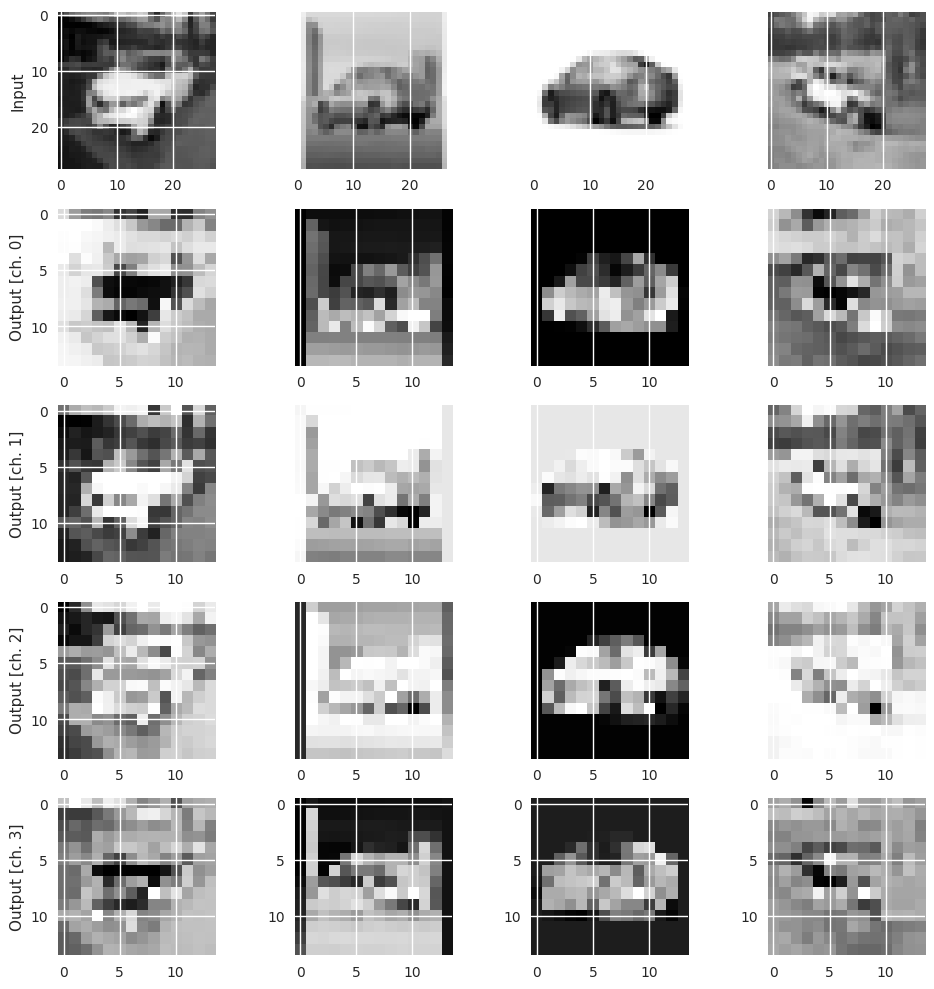

In [250]:
n_samples = 4
n_channels = 4
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(10, 10))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_images[k, :, :, 0], cmap="gray")

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, :, c], cmap="gray")

plt.tight_layout()
plt.show()

Below each input image, the $4$ output channels generated by the quantum
convolution are visualized in gray scale.

One can clearly notice the downsampling of the resolution and some local
distortion introduced by the quantum kernel. On the other hand the
global shape of the image is preserved, as expected for a convolution
layer.


# Hybrid quantum-classical model

After the application of the quantum convolution layer we feed the
resulting features into a classical neural network that will be trained
to classify the $10$ different digits of the MNIST dataset.

We use a very simple model: just a fully connected layer with 10 output
nodes with a final *softmax* activation function.

The model is compiled with a *stochastic-gradient-descent* optimizer,
and a *cross-entropy* loss function.


In [251]:
def MyModel():
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Flatten(),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Training

We first initialize an instance of the model, then we train and validate
it with the dataset that has been already pre-processed by a quantum
convolution.


In [252]:
q_model = MyModel()

q_history = q_model.fit(
    q_train_images,
    train_labels,
    validation_data=(q_test_images, test_labels),
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/50
41/41 - 0s - 12ms/step - accuracy: 0.2222 - loss: 1.7390 - val_accuracy: 0.2195 - val_loss: 1.8084
Epoch 2/50
41/41 - 0s - 3ms/step - accuracy: 0.3457 - loss: 1.5019 - val_accuracy: 0.2683 - val_loss: 1.7783
Epoch 3/50
41/41 - 0s - 3ms/step - accuracy: 0.4383 - loss: 1.3523 - val_accuracy: 0.2927 - val_loss: 1.7607
Epoch 4/50
41/41 - 0s - 3ms/step - accuracy: 0.5062 - loss: 1.2402 - val_accuracy: 0.2683 - val_loss: 1.7631
Epoch 5/50
41/41 - 0s - 2ms/step - accuracy: 0.5617 - loss: 1.1498 - val_accuracy: 0.2439 - val_loss: 1.7731
Epoch 6/50
41/41 - 0s - 2ms/step - accuracy: 0.5864 - loss: 1.0723 - val_accuracy: 0.2439 - val_loss: 1.7867
Epoch 7/50
41/41 - 0s - 2ms/step - accuracy: 0.6173 - loss: 1.0039 - val_accuracy: 0.2439 - val_loss: 1.8017
Epoch 8/50
41/41 - 0s - 2ms/step - accuracy: 0.6728 - loss: 0.9427 - val_accuracy: 0.2683 - val_loss: 1.8171
Epoch 9/50
41/41 - 0s - 2ms/step - accuracy: 0.7346 - loss: 0.8871 - val_accuracy: 0.2683 - val_loss: 1.8325
Epoch 10/50
41/41 

In order to compare the results achievable with and without the quantum
convolution layer, we initialize also a \"classical\" instance of the
model that will be directly trained and validated with the raw MNIST
images (i.e., without quantum pre-processing).


In [253]:
c_model = MyModel()

c_history = c_model.fit(
    train_images,
    train_labels,
    validation_data=(test_images, test_labels),
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/50
41/41 - 0s - 11ms/step - accuracy: 0.2160 - loss: 1.7761 - val_accuracy: 0.2683 - val_loss: 1.6034
Epoch 2/50
41/41 - 0s - 2ms/step - accuracy: 0.2840 - loss: 1.7533 - val_accuracy: 0.2683 - val_loss: 1.6286
Epoch 3/50
41/41 - 0s - 2ms/step - accuracy: 0.2963 - loss: 1.7180 - val_accuracy: 0.2439 - val_loss: 1.6446
Epoch 4/50
41/41 - 0s - 2ms/step - accuracy: 0.3210 - loss: 1.6797 - val_accuracy: 0.2439 - val_loss: 1.6486
Epoch 5/50
41/41 - 0s - 2ms/step - accuracy: 0.3210 - loss: 1.6462 - val_accuracy: 0.2195 - val_loss: 1.6513
Epoch 6/50
41/41 - 0s - 3ms/step - accuracy: 0.3457 - loss: 1.6159 - val_accuracy: 0.2195 - val_loss: 1.6547
Epoch 7/50
41/41 - 0s - 3ms/step - accuracy: 0.3704 - loss: 1.5879 - val_accuracy: 0.2439 - val_loss: 1.6589
Epoch 8/50
41/41 - 0s - 2ms/step - accuracy: 0.3642 - loss: 1.5616 - val_accuracy: 0.2439 - val_loss: 1.6636
Epoch 9/50
41/41 - 0s - 2ms/step - accuracy: 0.3642 - loss: 1.5367 - val_accuracy: 0.2195 - val_loss: 1.6687
Epoch 10/50
41/41 

# Results

We can finally plot the test accuracy and the test loss with respect to
the number of training epochs.


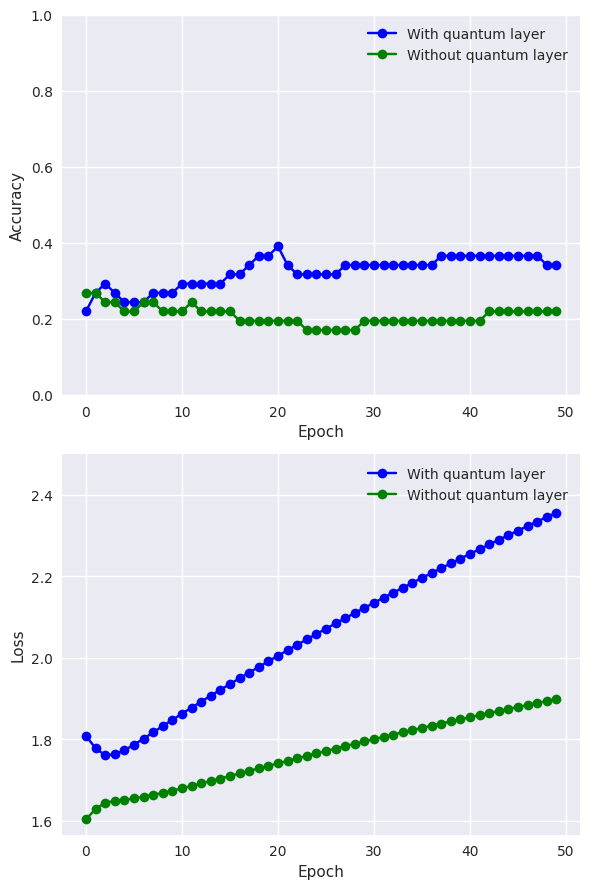

In [254]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

ax1.plot(q_history.history["val_accuracy"], "-ob", label="With quantum layer")
ax1.plot(c_history.history["val_accuracy"], "-og", label="Without quantum layer")
ax1.set_ylabel("Accuracy")
ax1.set_ylim([0, 1])
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["val_loss"], "-ob", label="With quantum layer")
ax2.plot(c_history.history["val_loss"], "-og", label="Without quantum layer")
ax2.set_ylabel("Loss")
ax2.set_ylim(top=2.5)
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()

1.  Maxwell Henderson, Samriddhi Shakya, Shashindra Pradhan, Tristan
    Cook. \"Quanvolutional Neural Networks: Powering Image Recognition
    with Quantum Circuits.\"
    [arXiv:1904.04767](https://arxiv.org/abs/1904.04767), 2019.
